# Speech Emotion Recognition using CNN+LSTM (PyTorch)



## Table of Contents
1. [Setup & GPU Check](#setup)
2. [Data Loading & Preprocessing](#data)
3. [Feature Extraction](#features)
4. [Data Augmentation](#augmentation)
5. [CNN+LSTM Model Architecture](#model)
6. [Training](#training)
7. [Evaluation & Results](#evaluation)


---

<a id="setup"></a>
## 1. Setup & GPU Check

In [ ]:
# Import required libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import time
from tqdm import tqdm

# PyTorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn.functional as F

# Scikit-learn utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



✅ Libraries imported successfully!


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"✅ GPU is available!")
    print(f"   Device: {torch.cuda.get_device_name(0)}")
    print(f"   CUDA Version: {torch.version.cuda}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    print(f"\n🚀 Training will use GPU acceleration!")
else:
    print(f"⚠️ GPU not available, using CPU")
    print(f"   Training will be slower")

print(f"\nSelected device: {device}")

GPU STATUS CHECK
PyTorch Version: 2.7.1+cu118
CUDA Available: True
✅ GPU is available!
   Device: NVIDIA GeForce RTX 3060 Laptop GPU
   CUDA Version: 11.8
   Memory: 6.44 GB

🚀 Training will use GPU acceleration!

Selected device: cuda


<a id="data"></a>
## 2. Data Loading & Preprocessing

In [3]:
# Load training data and labels

train_X = np.load("training_data_projectC.npy").T  # Shape: (900, 144000)
train_t = np.load("training_labels_projectC.npy")  # Shape: (900,)


print(f"   Audio data shape: {train_X.shape}")
print(f"   Labels shape: {train_t.shape}")
print(f"   Number of samples: {train_X.shape[0]}")
print(f"   Audio length per sample: {train_X.shape[1]} samples")
print(f"   Number of classes: {len(np.unique(train_t))}")
print(f"   Class labels: {np.unique(train_t)}")

# Check class distribution
print(f"\nClass distribution:")
unique, counts = np.unique(train_t, return_counts=True)
for label, count in zip(unique, counts):
    print(f"   Class {int(label)}: {count} samples ({count/len(train_t)*100:.1f}%)")

   Audio data shape: (900, 144000)
   Labels shape: (900,)
   Number of samples: 900
   Audio length per sample: 144000 samples
   Number of classes: 5
   Class labels: [1. 2. 3. 4. 5.]

Class distribution:
   Class 1: 182 samples (20.2%)
   Class 2: 180 samples (20.0%)
   Class 3: 181 samples (20.1%)
   Class 4: 175 samples (19.4%)
   Class 5: 182 samples (20.2%)


In [4]:
# Prepare labels for deep learning
# Convert labels to 0-indexed (1,2,3,4,5 -> 0,1,2,3,4)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(train_t)

num_classes = len(np.unique(y_encoded))

print(f"Original labels (first 10): {train_t[:10]}")
print(f"Encoded labels (first 10): {y_encoded[:10]}")
print(f"Number of classes: {num_classes}")

Original labels (first 10): [3. 1. 2. 2. 3. 5. 2. 3. 1. 1.]
Encoded labels (first 10): [2 0 1 1 2 4 1 2 0 0]
Number of classes: 5


<a id="features"></a>
## 3. Feature Extraction

In [5]:
# Audio processing parameters
sr = 48000          # Sample rate
N_fft = 1024        # FFT window size
HOP_len = 512       # Hop length
N_melband = 128     # Number of mel bands
f_max = 8000        # Maximum frequency (Hz)

print("Audio Processing Configuration:")
print(f"  Sample Rate: {sr} Hz")
print(f"  FFT Window: {N_fft}")
print(f"  Hop Length: {HOP_len}")
print(f"  Mel Bands: {N_melband}")
print(f"  Max Frequency: {f_max} Hz")

Audio Processing Configuration:
  Sample Rate: 48000 Hz
  FFT Window: 1024
  Hop Length: 512
  Mel Bands: 128
  Max Frequency: 8000 Hz


In [ ]:

start_time = time.time()

melspec = librosa.feature.melspectrogram(
    y=train_X,
    sr=sr,
    n_fft=N_fft,
    hop_length=HOP_len,
    n_mels=N_melband,
    fmax=f_max,
)

# Convert to log scale (dB)
melspec_db = librosa.power_to_db(melspec, ref=np.max)

print(f"   Shape: {melspec_db.shape}")  # (900, 128, 282)
print(f"   Time taken: {time.time() - start_time:.2f} seconds")
print(f"\n   Dimensions:")
print(f"   - Samples: {melspec_db.shape[0]}")
print(f"   - Mel bands (frequency): {melspec_db.shape[1]}")
print(f"   - Time frames: {melspec_db.shape[2]}")

Extracting mel-spectrograms...
✅ Mel-spectrogram extraction completed!
   Shape: (900, 128, 282)
   Time taken: 8.00 seconds

   Dimensions:
   - Samples: 900
   - Mel bands (frequency): 128
   - Time frames: 282


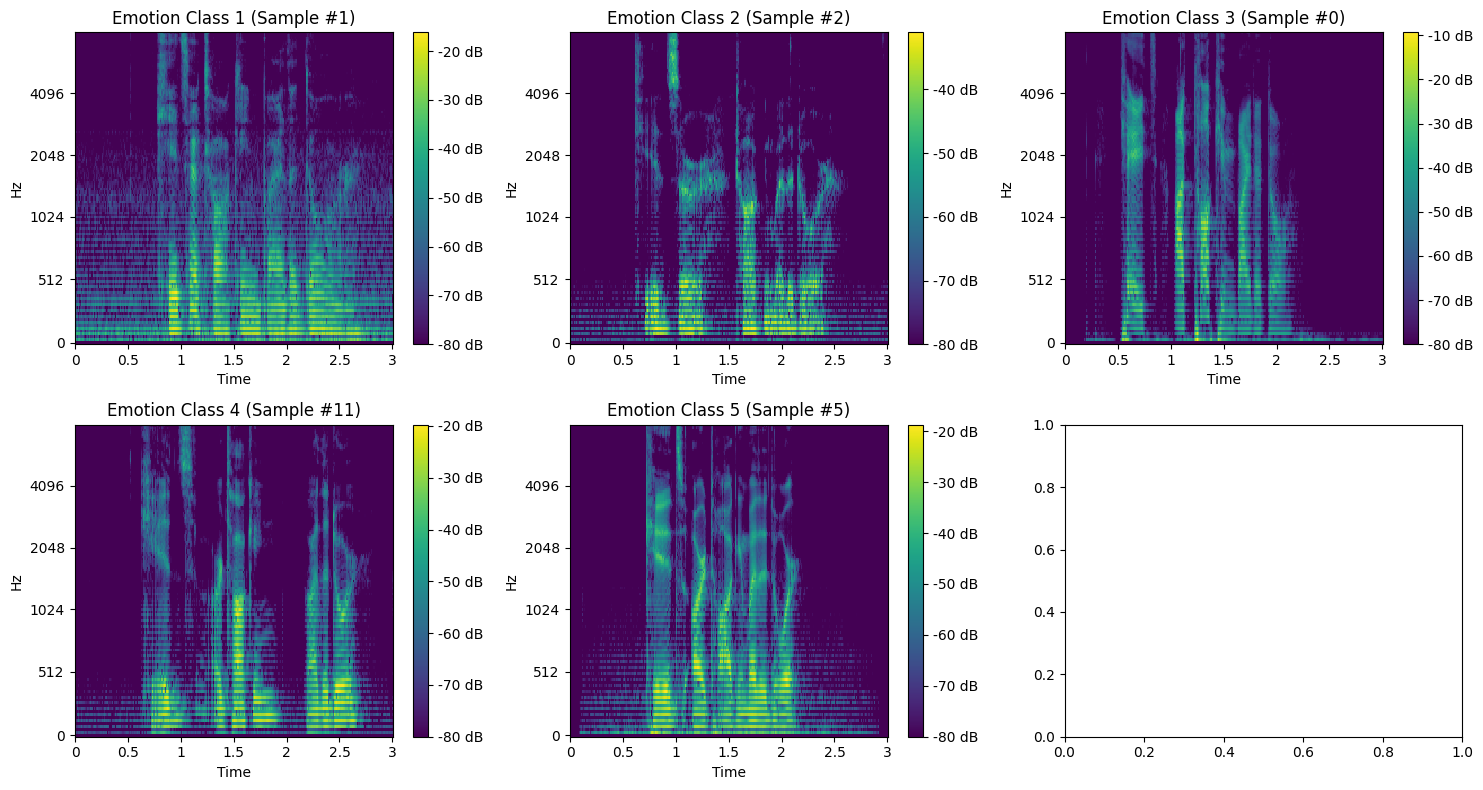

In [7]:
# Visualize sample mel-spectrograms
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, emotion_class in enumerate(np.unique(train_t)):
    # Find first sample of this emotion
    sample_idx = np.where(train_t == emotion_class)[0][0]
    
    # Plot mel-spectrogram
    img = librosa.display.specshow(
        melspec_db[sample_idx],
        x_axis='time',
        y_axis='mel',
        sr=sr,
        fmax=f_max,
        ax=axes[i],
        cmap='viridis'
    )
    axes[i].set_title(f'Emotion Class {int(emotion_class)} (Sample #{sample_idx})')
    fig.colorbar(img, ax=axes[i], format='%+2.0f dB')

plt.tight_layout()
plt.show()

In [8]:
# Reshape data for PyTorch CNN
# PyTorch expects: (batch, channels, height, width)
# Our data: (samples, freq_bands, time_steps) -> (samples, 1, freq_bands, time_steps)

X_reshaped = melspec_db[:, np.newaxis, :, :]  # Add channel dimension

print(f"Original shape: {melspec_db.shape}")
print(f"Reshaped for PyTorch CNN: {X_reshaped.shape}")
print(f"\nDimension interpretation:")
print(f"  Samples: {X_reshaped.shape[0]}")
print(f"  Channels: {X_reshaped.shape[1]} (mono audio)")
print(f"  Frequency bins: {X_reshaped.shape[2]}")
print(f"  Time steps: {X_reshaped.shape[3]}")

Original shape: (900, 128, 282)
Reshaped for PyTorch CNN: (900, 1, 128, 282)

Dimension interpretation:
  Samples: 900
  Channels: 1 (mono audio)
  Frequency bins: 128
  Time steps: 282


### Train/Validation/Test Split

In [ ]:
# Split data: 70% train, 15% validation, 15% test
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_reshaped, y_encoded,
    test_size=0.15,
    stratify=y_encoded,
    random_state=2025
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.176,  # 0.176 * 0.85 ≈ 0.15 of total
    stratify=y_train_val,
    random_state=2025
)

print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/X_reshaped.shape[0]*100:.1f}%)")
print(f"Validation set: {X_val.shape[0]} samples ({X_val.shape[0]/X_reshaped.shape[0]*100:.1f}%)")
print(f"Test set: {X_test.shape[0]} samples ({X_test.shape[0]/X_reshaped.shape[0]*100:.1f}%)")

# Verify class distribution
print("\nClass distribution:")
for split_name, y_split in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    unique, counts = np.unique(y_split, return_counts=True)
    print(f"  {split_name}: {dict(zip(unique, counts))}")

Training set: 630 samples (70.0%)
Validation set: 135 samples (15.0%)
Test set: 135 samples (15.0%)

Class distribution:
  Train: {np.int64(0): np.int64(127), np.int64(1): np.int64(126), np.int64(2): np.int64(127), np.int64(3): np.int64(123), np.int64(4): np.int64(127)}
  Val: {np.int64(0): np.int64(27), np.int64(1): np.int64(27), np.int64(2): np.int64(27), np.int64(3): np.int64(26), np.int64(4): np.int64(28)}
  Test: {np.int64(0): np.int64(28), np.int64(1): np.int64(27), np.int64(2): np.int64(27), np.int64(3): np.int64(26), np.int64(4): np.int64(27)}


<a id="augmentation"></a>
## 4. Data Augmentation

In [ ]:
# Data augmentation functions (5x augmentation configuration)
def add_noise_torch(data, noise_factor=0.005):
    """Add random Gaussian noise"""
    noise = torch.randn_like(data) * noise_factor
    return data + noise

def time_shift_torch(data, shift_max=0.2):
    """Shift audio in time domain"""
    shift = int(data.shape[-1] * shift_max * torch.rand(1).item())
    direction = 1 if torch.rand(1).item() > 0.5 else -1
    return torch.roll(data, shifts=shift * direction, dims=-1)

def volume_scale_torch(data, scale_range=(0.8, 1.2)):
    """Change volume (amplitude scaling)"""
    scale = scale_range[0] + (scale_range[1] - scale_range[0]) * torch.rand(1).item()
    return data * scale

def augment_batch(batch_x, batch_y, augmentation_factor=5):
    """Apply random augmentations to a batch"""
    augmented_x = [batch_x]
    augmented_y = [batch_y]
    
    for _ in range(augmentation_factor - 1):
        x_aug = batch_x.clone()
        
        # Randomly apply augmentations (higher probability)
        if torch.rand(1).item() > 0.3:
            x_aug = add_noise_torch(x_aug, noise_factor=0.008)
        if torch.rand(1).item() > 0.3:
            x_aug = time_shift_torch(x_aug, shift_max=0.25)
        if torch.rand(1).item() > 0.3:
            x_aug = volume_scale_torch(x_aug, scale_range=(0.7, 1.3))
        
        augmented_x.append(x_aug)
        augmented_y.append(batch_y)
    
    return torch.cat(augmented_x, dim=0), torch.cat(augmented_y, dim=0)

print("   - Gaussian noise addition")
print("   - Time shifting")
print("   - Volume scaling (loudness change)")
print(f"   - Augmentation factor: 5x (quintuple the training data)")

✅ Data augmentation functions defined:
   - Gaussian noise addition
   - Time shifting
   - Volume scaling (loudness change)
   - Augmentation factor: 5x (quintuple the training data)


In [ ]:
# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train)
y_train_tensor = torch.LongTensor(y_train)
X_val_tensor = torch.FloatTensor(X_val)
y_val_tensor = torch.LongTensor(y_val)
X_test_tensor = torch.FloatTensor(X_test)
y_test_tensor = torch.LongTensor(y_test)

print(f"   Train: {X_train_tensor.shape}, dtype={X_train_tensor.dtype}")
print(f"   Val: {X_val_tensor.shape}, dtype={X_val_tensor.dtype}")
print(f"   Test: {X_test_tensor.shape}, dtype={X_test_tensor.dtype}")

✅ Data converted to PyTorch tensors
   Train: torch.Size([630, 1, 128, 282]), dtype=torch.float32
   Val: torch.Size([135, 1, 128, 282]), dtype=torch.float32
   Test: torch.Size([135, 1, 128, 282]), dtype=torch.float32


In [ ]:
# Create DataLoaders
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


print(f"   Train batches: {len(train_loader)}")
print(f"   Val batches: {len(val_loader)}")
print(f"   Test batches: {len(test_loader)}")

✅ DataLoaders created (batch_size=32)
   Train batches: 20
   Val batches: 5
   Test batches: 5


<a id="model"></a>
## 5. CNN+LSTM Model Architecture

Build a hybrid CNN+LSTM model:
- **CNN layers**: Extract spatial features from mel-spectrogram
- **LSTM layers**: Capture temporal dependencies
- **Dense layers**: Final classification

In [13]:
class CNN_LSTM_EmotionClassifier(nn.Module):
    def __init__(self, num_classes=5, lstm_hidden_size=128, lstm_num_layers=2, dropout=0.3):
        super(CNN_LSTM_EmotionClassifier, self).__init__()
        
        # CNN layers for feature extraction (3 layers)
        self.conv1 = nn.Conv2d(1, 32, kernel_size=(3, 3), padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.pool1 = nn.MaxPool2d(kernel_size=(2, 2))
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=(3, 3), padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.pool2 = nn.MaxPool2d(kernel_size=(2, 2))
        
        self.conv3 = nn.Conv2d(64, 128, kernel_size=(3, 3), padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool3 = nn.MaxPool2d(kernel_size=(2, 2))
        
        self.dropout_cnn = nn.Dropout(dropout)
        
        # Calculate the size after CNN layers
        # Input: (batch, 1, 128, 282)
        # After 3 pooling layers: (batch, 128, 16, 35)
        self.cnn_output_size = 128 * 16  # channels * height
        
        # LSTM layers for temporal modeling (2 layers)
        self.lstm = nn.LSTM(
            input_size=self.cnn_output_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            batch_first=True,
            dropout=dropout if lstm_num_layers > 1 else 0,
            bidirectional=True
        )
        
        # Fully connected layers
        self.dropout_lstm = nn.Dropout(dropout)
        self.fc1 = nn.Linear(lstm_hidden_size * 2, 128)  # *2 for bidirectional
        self.dropout_fc = nn.Dropout(dropout)
        self.fc2 = nn.Linear(128, num_classes)
        
    def forward(self, x):
        # CNN feature extraction
        # Input: (batch, 1, 128, 282)
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool1(x)  # (batch, 32, 64, 141)
        
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool2(x)  # (batch, 64, 32, 70)
        
        x = F.relu(self.bn3(self.conv3(x)))
        x = self.pool3(x)  # (batch, 128, 16, 35)
        
        x = self.dropout_cnn(x)
        
        # Reshape for LSTM: (batch, time_steps, features)
        batch_size, channels, height, width = x.size()
        x = x.permute(0, 3, 1, 2)  # (batch, width, channels, height)
        x = x.reshape(batch_size, width, channels * height)  # (batch, 35, 128*16)
        
        # LSTM temporal modeling
        lstm_out, (h_n, c_n) = self.lstm(x)
        
        # Use last time step output
        x = lstm_out[:, -1, :]
        x = self.dropout_lstm(x)
        
        # Fully connected layers
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)
        
        return x


In [ ]:
# Initialize model (proven configuration)
model = CNN_LSTM_EmotionClassifier(
    num_classes=num_classes,
    lstm_hidden_size=128,
    lstm_num_layers=2,
    dropout=0.3 
).to(device)

# Print model summary

print(model)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")


MODEL ARCHITECTURE
CNN_LSTM_EmotionClassifier(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0, dilation=1, ceil_mode=False)
  (dropout_cnn): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(2048, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (dropout_lstm): Dropout(p=

<a id="training"></a>
## 6. Training

In [15]:
# Training configuration
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

num_epochs = 200
best_val_acc = 0.0
patience = 35
patience_counter = 0

In [16]:
# Training loop with data augmentation (5x)
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("\n🚀 Starting training with 5x augmentation...\n")
start_time = time.time()

for epoch in range(num_epochs):
    # Training phase with augmentation
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0
    
    train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
    for batch_x, batch_y in train_pbar:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        
        # Apply data augmentation (5x augmentation factor)
        batch_x_aug, batch_y_aug = augment_batch(batch_x, batch_y, augmentation_factor=5)
        
        # Forward pass
        outputs = model(batch_x_aug)
        loss = criterion(outputs, batch_y_aug)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Statistics
        train_loss += loss.item() * batch_x_aug.size(0)
        _, predicted = torch.max(outputs, 1)
        train_total += batch_y_aug.size(0)
        train_correct += (predicted == batch_y_aug).sum().item()
        
        # Update progress bar
        train_pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100 * train_correct / train_total:.2f}%'
        })
    
    train_loss = train_loss / (len(train_dataset) * 5)  # Account for 5x augmentation
    train_acc = 100 * train_correct / train_total
    
    # Validation phase (no augmentation)
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]  ')
        for batch_x, batch_y in val_pbar:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            
            val_loss += loss.item() * batch_x.size(0)
            _, predicted = torch.max(outputs, 1)
            val_total += batch_y.size(0)
            val_correct += (predicted == batch_y).sum().item()
            
            val_pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc': f'{100 * val_correct / val_total:.2f}%'
            })
    
    val_loss = val_loss / len(val_dataset)
    val_acc = 100 * val_correct / val_total
    
    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # Learning rate scheduling
    scheduler.step(val_loss)
    
    # Print epoch summary
    print(f'\nEpoch {epoch+1}/{num_epochs} Summary:')
    print(f'  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%')
    print(f'  Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%')
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_cnn_lstm_model_v3.pth')
        print(f'  ✅ New best model saved! (Val Acc: {val_acc:.2f}%)')
        patience_counter = 0
    else:
        patience_counter += 1
        print(f'  No improvement ({patience_counter}/{patience})')
    
    # Early stopping
    if patience_counter >= patience:
        print(f'\n⏹️ Early stopping triggered at epoch {epoch+1}')
        break
    
    print('-' * 70)

training_time = time.time() - start_time
print(f'\n✅ Training completed!')
print(f'   Total time: {training_time/60:.2f} minutes')
print(f'   Best validation accuracy: {best_val_acc:.2f}%')


🚀 Starting training with 5x augmentation...



Epoch 1/200 [Val]  : 100%|██████████| 5/5 [00:00<00:00, 22.28it/s, loss=1.6568, acc=21.48%]



Epoch 1/200 Summary:
  Train Loss: 1.6085, Train Acc: 22.00%
  Val Loss: 1.5941, Val Acc: 21.48%
  ✅ New best model saved! (Val Acc: 21.48%)
----------------------------------------------------------------------


Epoch 2/200 [Val]  : 100%|██████████| 5/5 [00:00<00:00, 22.23it/s, loss=1.5807, acc=34.81%]



Epoch 2/200 Summary:
  Train Loss: 1.5880, Train Acc: 25.17%
  Val Loss: 1.5391, Val Acc: 34.81%
  ✅ New best model saved! (Val Acc: 34.81%)
----------------------------------------------------------------------


...


Epoch 109/200 Summary:
  Train Loss: 0.0247, Train Acc: 99.30%
  Val Loss: 0.6779, Val Acc: 85.93%
  No improvement (33/35)
----------------------------------------------------------------------


Epoch 110/200 [Val]  : 100%|██████████| 5/5 [00:00<00:00, 63.78it/s, loss=0.8400, acc=85.93%]



Epoch 110/200 Summary:
  Train Loss: 0.0256, Train Acc: 99.14%
  Val Loss: 0.6519, Val Acc: 85.93%
  No improvement (34/35)
----------------------------------------------------------------------


Epoch 111/200 [Val]  : 100%|██████████| 5/5 [00:00<00:00, 68.57it/s, loss=0.8410, acc=85.93%]


Epoch 111/200 Summary:
  Train Loss: 0.0177, Train Acc: 99.46%
  Val Loss: 0.6621, Val Acc: 85.93%
  No improvement (35/35)

⏹️ Early stopping triggered at epoch 111

✅ Training completed!
   Total time: 58.36 minutes
   Best validation accuracy: 88.89%


<a id="evaluation"></a>
## 7. Evaluation & Results

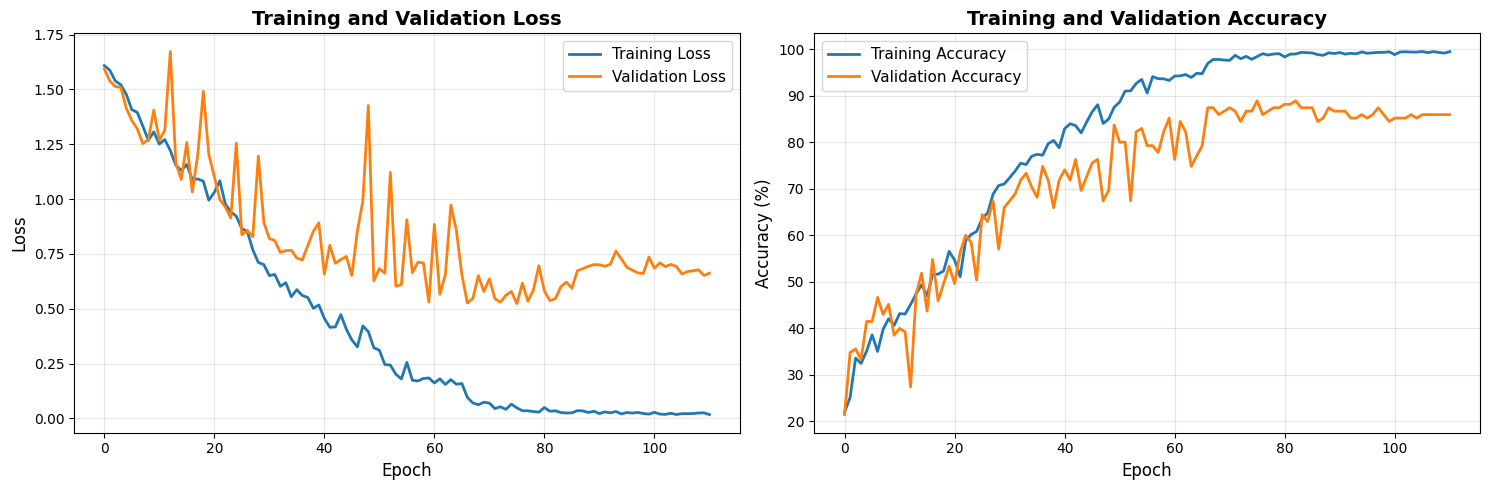

📊 Training Summary:
   Total epochs: 111
   Best validation accuracy: 88.89%
   Final training accuracy: 99.46%
   Final validation accuracy: 85.93%


In [22]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot loss
axes[0].plot(train_losses, label='Training Loss', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Plot accuracy
axes[1].plot(train_accs, label='Training Accuracy', linewidth=2)
axes[1].plot(val_accs, label='Validation Accuracy', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Training Summary:")
print(f"   Total epochs: {len(train_losses)}")
print(f"   Best validation accuracy: {best_val_acc:.2f}%")
print(f"   Final training accuracy: {train_accs[-1]:.2f}%")
print(f"   Final validation accuracy: {val_accs[-1]:.2f}%")

In [26]:

model.load_state_dict(torch.load('best_cnn_lstm_model_v3.pth'))
model.eval()

# Evaluate on test set
test_preds = []
test_labels = []

with torch.no_grad():
    for batch_x, batch_y in tqdm(test_loader, desc='Testing'):
        batch_x = batch_x.to(device)
        outputs = model(batch_x)
        _, predicted = torch.max(outputs, 1)
        
        test_preds.extend(predicted.cpu().numpy())
        test_labels.extend(batch_y.numpy())

# Convert to numpy arrays
test_preds = np.array(test_preds)
test_labels = np.array(test_labels)

# Calculate test accuracy
test_accuracy = accuracy_score(test_labels, test_preds) * 100

print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Samples: {len(test_labels)}")
print("="*70)

Testing: 100%|██████████| 5/5 [00:00<00:00, 19.53it/s]

Test Accuracy: 87.41%
Test Samples: 135


In [27]:
# Map back to original labels (0,1,2,3,4 -> 1,2,3,4,5)
original_test_labels = label_encoder.inverse_transform(test_labels)
original_test_preds = label_encoder.inverse_transform(test_preds)

# Emotion labels (adjust based on your dataset)
emotion_names = ['Emotion 1', 'Emotion 2', 'Emotion 3', 'Emotion 4', 'Emotion 5']

print(classification_report(
    test_labels, 
    test_preds, 
    target_names=emotion_names,
    digits=4
))

# Per-class accuracy
print("\n PER-CLASS ACCURACY")

for i, emotion in enumerate(emotion_names):
    class_mask = test_labels == i
    class_acc = accuracy_score(test_labels[class_mask], test_preds[class_mask]) * 100
    class_count = np.sum(class_mask)
    print(f"{emotion}: {class_acc:.2f}% ({class_count} samples)")


              precision    recall  f1-score   support

   Emotion 1     0.8621    0.8929    0.8772        28
   Emotion 2     0.9200    0.8519    0.8846        27
   Emotion 3     0.9524    0.7407    0.8333        27
   Emotion 4     0.8333    0.9615    0.8929        26
   Emotion 5     0.8333    0.9259    0.8772        27

    accuracy                         0.8741       135
   macro avg     0.8802    0.8746    0.8730       135
weighted avg     0.8804    0.8741    0.8729       135


 PER-CLASS ACCURACY
Emotion 1: 89.29% (28 samples)
Emotion 2: 85.19% (27 samples)
Emotion 3: 74.07% (27 samples)
Emotion 4: 96.15% (26 samples)
Emotion 5: 92.59% (27 samples)


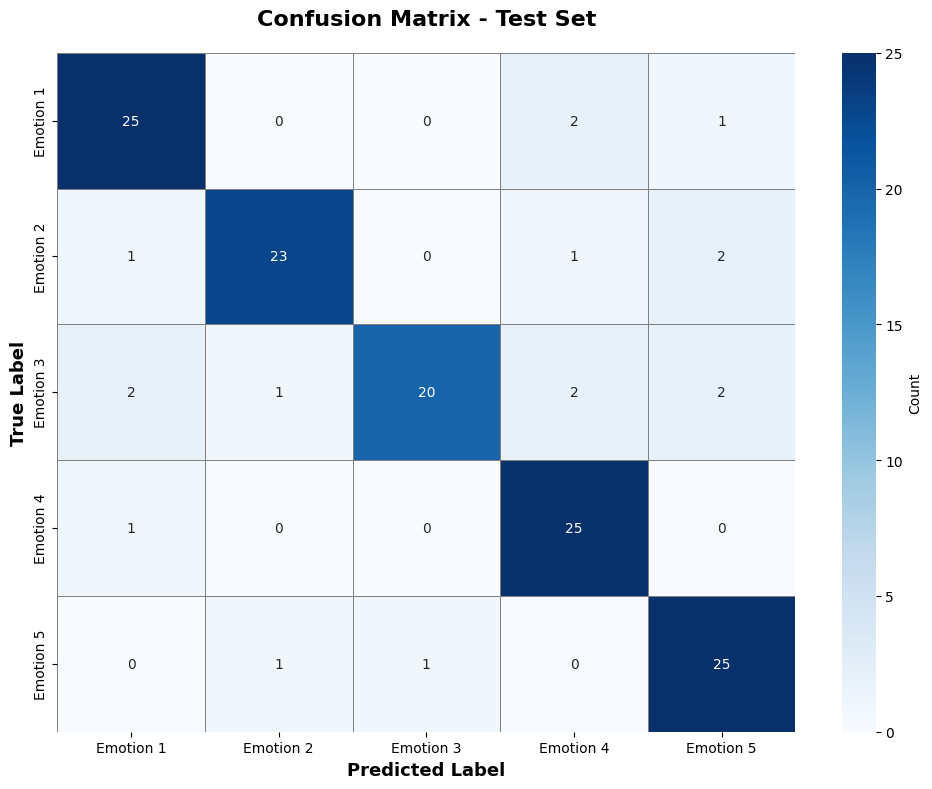

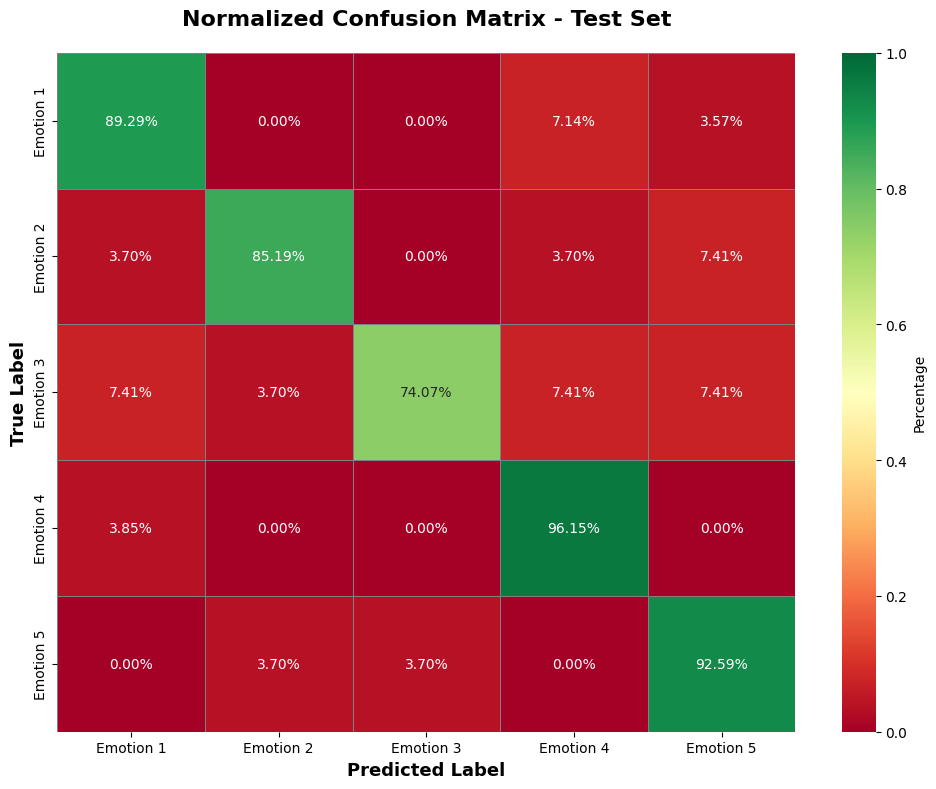

In [20]:
# Visualize confusion matrix
import seaborn as sns

cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    cbar_kws={'label': 'Count'},
    linewidths=0.5,
    linecolor='gray'
)

plt.title('Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_normalized, 
    annot=True, 
    fmt='.2%', 
    cmap='RdYlGn',
    xticklabels=emotion_names,
    yticklabels=emotion_names,
    cbar_kws={'label': 'Percentage'},
    linewidths=0.5,
    linecolor='gray',
    vmin=0,
    vmax=1
)

plt.title('Normalized Confusion Matrix - Test Set', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=13, fontweight='bold')
plt.ylabel('True Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()